### Imports and Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import warnings
from scipy.stats import linregress
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

base_dir = os.getcwd()
parent_dir = os.path.dirname(base_dir)
os.chdir(parent_dir)

np.random.seed(101)

print(f"Current Directory: {os.getcwd()}")

Current Directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study


### Model performance barplot

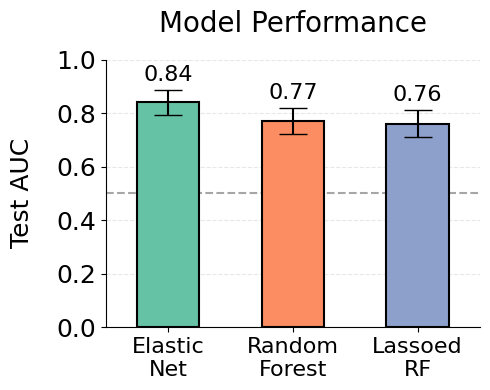

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the fold-level results we just saved
df_results = pd.read_csv("../data/procdata/1_doublingRate/ModelZoo_Fold_Results.csv")
model_names = ["ElasticNet", "LassoedRF", "RandomForest", ]

# 2. CALCULATE MEAN AND 95% CI MANUALLY
means = []
ci_95 = []
plot_colors_raw = ["#66c2a5", "#8da0cb", "#fc8d62"]

for m in model_names:
    fold_data = df_results[df_results["Model"] == m]["AUROC"].values
    mean_val = np.mean(fold_data)
    
    # Standard Error = SD / sqrt(N)
    std_err = np.std(fold_data) / np.sqrt(len(fold_data))
    
    # 95% CI is roughly 1.96 * Standard Error
    ci_val = 1.96 * std_err
    
    means.append(mean_val)
    ci_95.append(ci_val)

# Combine all plotting data into a list of tuples
combined = list(zip(means, ci_95, ["Elastic\nNet", "Lassoed\nRF", "Random\nForest"], plot_colors_raw))

# Sort by mean (the first element, index 0) in descending order
combined.sort(key=lambda x: x[0], reverse=True)

# Unpack them back into separate lists
sorted_means, sorted_ci, sorted_labels, sorted_colors = zip(*combined)

# 3. SETTINGS
plt.figure(figsize=(5, 4))
x_pos = np.arange(len(sorted_labels))

# 4. Baseline at 0.5
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)

# 5. THE BAR PLOT 
# We use yerr=ci_95 to show the Confidence Interval style from Seaborn
bars = plt.bar(x_pos + 0.5, sorted_means, yerr=sorted_ci, capsize=10, 
               color=sorted_colors, alpha=1, edgecolor='black', lw=1.5, width=0.5, zorder=2)

# 6. AESTHETICS (Matching your 16pt / 20pt fonts)
plt.ylabel('Test AUC', fontsize=18, labelpad=16)
plt.xticks(x_pos + 0.5, sorted_labels, fontsize=16)
plt.yticks(fontsize=18)
plt.xlim(0, 3) 
plt.ylim(0, 1.0) 
plt.title('Model Performance', fontsize=20, pad=20)

# 7. ADD THE LABELS (Exact AUC values)
for i, bar in enumerate(bars):
    height = bar.get_height()
    # Place label slightly above the CI error bar
    plt.text(bar.get_x() + bar.get_width()/2., height + sorted_ci[i] + 0.02,
             f'{height:.2f}', ha='center', va='bottom', fontsize=16)

# 8. CLEANUP
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/1_doublingRate/figure2e_Model_Comparison.png', dpi=300)
plt.show()

### figure2f ROC

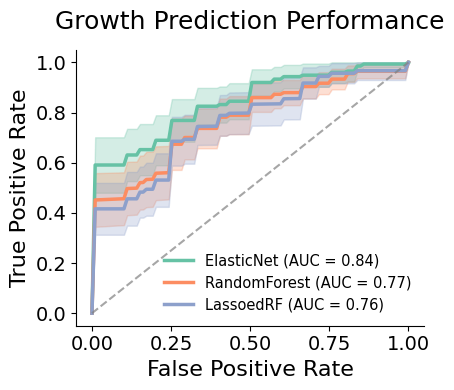

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. DATA & SETTINGS
df_preds = pd.read_csv("../data/procdata/1_doublingRate/MultiModel_All_Predictions.csv")

model_names = ["ElasticNet", "RandomForest", "LassoedRF"]
colors = {"RandomForest": "#fc8d62", "ElasticNet": "#66c2a5", "LassoedRF": "#8da0cb"}
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(4.5, 4))

for m in model_names:
    m_data = df_preds[df_preds["Model_Type"] == m]
    tprs = []
    
    for fold in m_data["Fold"].unique():
        f_df = m_data[m_data["Fold"] == fold]
        if len(np.unique(f_df["True_Label"])) < 2: continue
        
        fpr, tpr, _ = roc_curve(f_df["True_Label"], f_df["Prob_Slow"])
        # Interpolate to common x-axis
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
    
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    real_auc = auc(mean_fpr, mean_tpr) # Dynamic calculation
    
    # Plot Mean Line
    ax.plot(mean_fpr, mean_tpr, color=colors[m], lw=2.5, 
            label=f'{m} (AUC = {real_auc:.2f})')
    
    # 95% CI Shading
    tpr_std = np.std(tprs, axis=0)
    # Using SEM for the CI shading
    tpr_err = 1.96 * (tpr_std / np.sqrt(len(tprs)))
    ax.fill_between(mean_fpr, 
                    np.maximum(mean_tpr - tpr_err, 0), 
                    np.minimum(mean_tpr + tpr_err, 1), 
                    color=colors[m], alpha=0.15)
    ax.fill_between(mean_fpr, 
                    np.maximum(mean_tpr - tpr_err, 0), 
                    np.minimum(mean_tpr + tpr_err, 1), 
                    color=colors[m], alpha=0.15)

# 2. FINAL FORMATTING
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.7) # Diagonal baseline

ax.set_title('Growth Prediction Performance', fontsize=18, pad=15)
ax.set_xlabel('False Positive Rate', fontsize=16)
ax.set_ylabel('True Positive Rate', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)

ax.legend(loc="lower right", fontsize=10.5, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../results/1_doublingRate/figure2f_ROC.png", dpi=300)
plt.show()

### SHAP analysis for RF

<>:71: SyntaxWarning: invalid escape sequence '\m'
<>:71: SyntaxWarning: invalid escape sequence '\m'
/var/folders/cz/vb9sgz_s0050f8rq5mdgr_hc0000gn/T/ipykernel_14788/3861194691.py:71: SyntaxWarning: invalid escape sequence '\m'
  plt.gca().set_yticklabels([f"$\mathit{{{label.get_text()}}}$" for label in plt.gca().get_yticklabels()])


Final Model trained on 50 extreme samples.


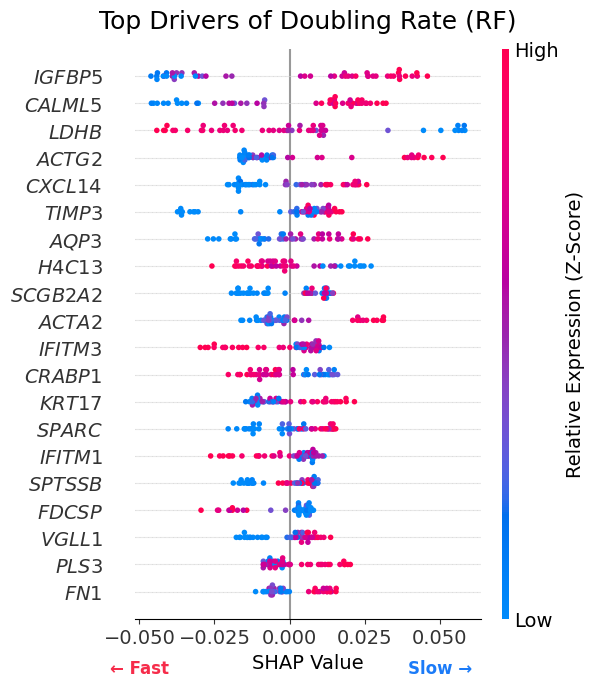

SHAP Summary Plot and CSV saved.


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier

N_HVG = 100

def select_hvg_train_only(X_train_df, n_hvg):
    return X_train_df.var(axis=0).sort_values(ascending=False).head(n_hvg).index.tolist()

# 1. LOAD DATA & REPLICATE EXTREMES LOGIC
# We use the same filtering as your 100-fold CV script
df = pd.read_csv("../data/procdata/1_doublingRate/rna_HVG2000_doubling_time_merged.csv", index_col=0)
X_df = df.drop(columns=["global_doubling_time"])
y_raw = np.log1p(df["global_doubling_time"].astype(float)).values

# Identify Extremes (33rd and 67th percentiles)
thr_low, thr_high = np.quantile(y_raw, 0.33), np.quantile(y_raw, 0.67)
mask = (y_raw <= thr_low) | (y_raw >= thr_high)

X_ext, y_ext = X_df.loc[mask], (y_raw[mask] >= thr_high).astype(int)

# 3. HVG Selection (Training Only)
hvg = select_hvg_train_only(X_ext, N_HVG)
X_ext_hvg= X_ext[hvg]

# 1. Save the full 100-gene list (often used as the 'query' for GO/KEGG)
pd.Series(hvg).to_csv("../results/1_doublingRate/Model_100_HVGs.csv", index=False, header=["Gene"])

# 2. TRAIN GLOBAL RANDOM FOREST
# We use the same RF_PARAMS from your ModelZoo script
RF_PARAMS = dict(n_estimators=500, max_depth=6, min_samples_leaf=1, max_features='sqrt', random_state=42, n_jobs=-1)
rf_final = RandomForestClassifier(**RF_PARAMS).fit(X_ext_hvg, y_ext)

print(f"Final Model trained on {len(X_ext_hvg)} extreme samples.")

# 3. COMPUTE SHAP VALUES
explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_ext_hvg)

# Check the structure of shap_values
# Sometimes depending on the sklearn version, it's just a single array for binary
if isinstance(shap_values, list):
    shap_val_slow = shap_values[1]
else:
    # If it's a single 3D array [samples, features, classes]
    shap_val_slow = shap_values[:, :, 1]

# 1. Tighter Figure Size (Tall and Narrower)
fig = plt.figure(figsize=(6, 7)) 

# 2. Plot with Plot_Size=None to prevent SHAP from overriding your figsize
shap.summary_plot(
    shap_val_slow, 
    X_ext_hvg, 
    max_display=20, 
    plot_size=None, 
    show=False,
    color_bar_label="Relative Expression"
)

# 3. INCREASE COLOR BAR FONT SIZE
# SHAP creates the color bar as the last axes in the figure
cb_ax = fig.axes[-1] 
cb_ax.set_ylabel("Relative Expression (Z-Score)", fontsize=14, labelpad=5) # Label size
cb_ax.tick_params(labelsize=14) # Tick size (Low/High)

# 3. ITALIZE GENE NAMES (Standard for Papers)
# This also makes the labels feel more "dense" and professional
plt.gca().set_yticklabels([f"$\mathit{{{label.get_text()}}}$" for label in plt.gca().get_yticklabels()])

# 4. TIGHTEN THE LAYOUT
plt.title("Top Drivers of Doubling Rate (RF)", fontsize=18, pad=15)
plt.xlabel("SHAP Value", fontsize=14)
# Manual Labels for Clarity
plt.text(-0.05, -3, "← Fast", color="#f62c4a", fontweight='bold', ha='center', fontsize=12)
plt.text(0.05, -3, "Slow →", color="#1b7bf8", fontweight='bold', ha='center', fontsize=12)


# Optional: Horizontal grid to separate gene rows
ax = plt.gca()
ax.grid(True, axis='y', color='lightgray', linestyle='-', alpha=0.5, zorder=0)

# Adjust tick label sizes for the compact view
plt.gca().tick_params(axis='both', which='major', labelsize=14)

# 5. REMOVE EXTRA PADDING
plt.tight_layout(pad=1.0) 
plt.savefig("../results/1_doublingRate/Figure2_SHAP_Compact.png", dpi=300, bbox_inches='tight')
plt.show()

# 5. EXPORT SHAP RANKING
# This creates a CSV of SHAP-based importance to compare with your Gini CSV
shap_importance = pd.DataFrame({
    'Gene': X_ext_hvg.columns,
    'Mean_Abs_SHAP': np.abs(shap_val_slow).mean(axis=0)
}).sort_values(by='Mean_Abs_SHAP', ascending=False)

shap_importance.to_csv("../results/1_doublingRate/SHAP_Global_Gene_Importance.csv", index=False)
print("SHAP Summary Plot and CSV saved.")

### ElasticNet coefficient plot

/Users/guanqiaofeng/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Exported 100 genes and full coefficients for KEGG/GO analysis.


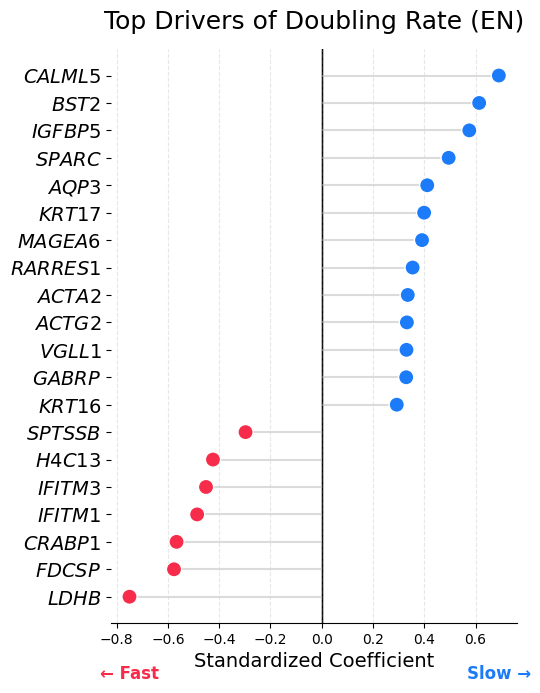

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. PREP DATA (Using the same 100 HVGs from your RF script)
# Assuming 'hvg' is the list of 100 genes from your previous step
X_final_df = X_ext[hvg] 
y_final = y_ext

# 2. SCALE DATA
# Crucial for ElasticNet: coefficients must be on the same scale to compare importance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final_df)

# 3. FIT GLOBAL MODEL
# Use the best params from your CV (Example: C=1.0, l1_ratio=0.1)
en_final = LogisticRegression(
    penalty='elasticnet', 
    solver='saga', 
    l1_ratio=0.1, 
    C=1.0, 
    max_iter=10000, 
    random_state=42
).fit(X_scaled, y_final)

# 4. EXTRACT & SORT COEFFICIENTS
coef_df = pd.DataFrame({
    'Gene': hvg,
    'Coef': en_final.coef_[0]
})
coef_df['Abs_Coef'] = coef_df['Coef'].abs()
top_20_en = coef_df.sort_values('Abs_Coef', ascending=False).head(20).sort_values('Coef')

# 2. Save the full Coefficient Table for GSEA
full_coef_df = pd.DataFrame({
    'Gene': hvg,
    'Coefficient': en_final.coef_[0]
}).sort_values('Coefficient', ascending=False)

full_coef_df.to_csv("../results/1_doublingRate/EN_Full_Coefficients_for_GSEA.csv", index=False)

print("Exported 100 genes and full coefficients for KEGG/GO analysis.")

# 5. DRAW THE LOLLIPOP PLOT
plt.figure(figsize=(5.5, 7))
colors = ['#f62c4a' if c < 0 else '#1b7bf8' for c in top_20_en['Coef']]

plt.hlines(y=range(len(top_20_en)), xmin=0, xmax=top_20_en['Coef'], color='lightgray', alpha=0.8)
plt.scatter(top_20_en['Coef'], range(len(top_20_en)), color=colors, s=120, zorder=3, edgecolors='white')

# Formatting
plt.yticks(range(len(top_20_en)), [fr"$\mathit{{{g}}}$" for g in top_20_en['Gene']], fontsize=14)
plt.axvline(0, color='black', lw=1, alpha=0.5)
plt.title("Top Drivers of Doubling Rate (EN)", fontsize=18, pad=15)
plt.xlabel("Standardized Coefficient", fontsize=14)
plt.yticks(fontsize=14)
sns.despine(left=True, top=True, right=True)
plt.axvline(0, color='black', lw=1, zorder=1)

# Manual Labels for Clarity
plt.text(top_20_en['Coef'].min(), -3, "← Fast", color="#f62c4a", fontweight='bold', ha='center', fontsize=12)
plt.text(top_20_en['Coef'].max(), -3, "Slow →", color="#1b7bf8", fontweight='bold', ha='center', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("../results/1_doublingRate/Figure2_ElasticNet_Coefficients.png", dpi=300)
plt.show()

### Comparison of EN and RF

<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
/var/folders/cz/vb9sgz_s0050f8rq5mdgr_hc0000gn/T/ipykernel_14788/1309960838.py:38: SyntaxWarning: invalid escape sequence '\m'
  f"$\mathit{{{row['Gene']}}}$", fontsize=9, fontweight='bold')


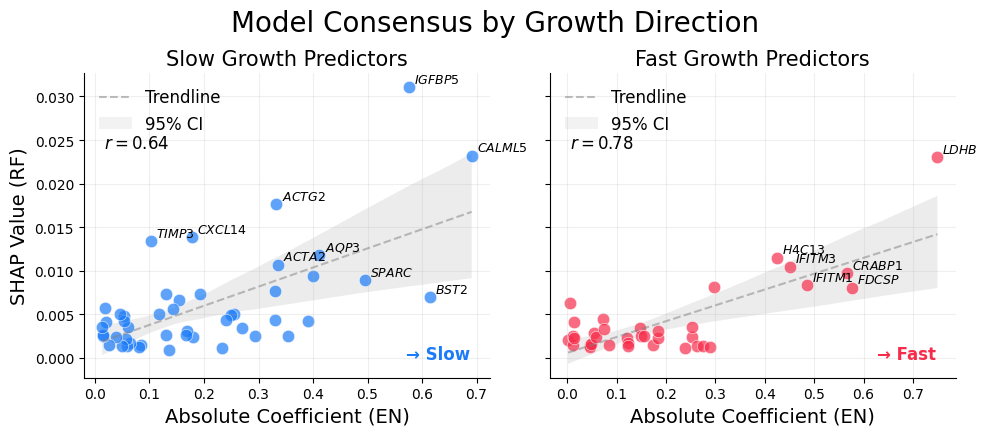

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# 1. LOAD & PREP DATA
en_df = pd.read_csv("../results/1_doublingRate/EN_Full_Coefficients_for_GSEA.csv")
shap_df = pd.read_csv("../results/1_doublingRate/SHAP_Global_Gene_Importance.csv")

merged = pd.merge(en_df, shap_df, on="Gene")
merged['Abs_Coefficient'] = merged['Coefficient'].abs()

# Split into two groups
slow_genes = merged[merged['Coefficient'] > 0].copy()
fast_genes = merged[merged['Coefficient'] < 0].copy()

# 2. SET UP PLOT
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

def plot_consensus(df, ax, title, color, label_text):
    # Calculate group-specific correlation
    r_val = df['Abs_Coefficient'].corr(df['Mean_Abs_SHAP'])
    
    # Regression line
    sns.regplot(data=df, x='Abs_Coefficient', y='Mean_Abs_SHAP', ax=ax,
                scatter=False, line_kws={'color':'gray', 'lw':1.5, 'linestyle':'--', 'alpha':0.5})
    
    # Scatter dots
    ax.scatter(df['Abs_Coefficient'], df['Mean_Abs_SHAP'], 
               c=color, s=80, alpha=0.7, edgecolors='white', linewidth=0.5)
    
    # Annotations (Threshold: SHAP > 0.01 or Abs_Coef > 0.4)
    top = df[(df['Mean_Abs_SHAP'] > 0.01) | (df['Abs_Coefficient'] > 0.4)]
    for i, row in top.iterrows():
        ax.text(row['Abs_Coefficient'] + 0.01, row['Mean_Abs_SHAP'] + 0.0005, 
                f"$\mathit{{{row['Gene']}}}$", fontsize=9, fontweight='bold')

    # Formatting
    ax.set_title(f"{title}", fontsize=15)
    ax.text(0.05, 0.80, f"$r = {r_val:.2f}$", transform=ax.transAxes, 
        fontsize=12, fontweight='bold', verticalalignment='top')
    ax.set_xlabel("Absolute Coefficient (EN)", fontsize=14)
    ax.grid(alpha=0.2)
    
    # Add group label indicator
    ax.text(0.95, 0.05, label_text, transform=ax.transAxes, 
            fontsize=12, fontweight='bold', color=color, ha='right', va='bottom')
    
    # Create legend elements
    legend_elements = [
        Line2D([0], [0], color='gray', lw=1.5, linestyle='--', alpha=0.5, label='Trendline'),
        Patch(facecolor='gray', alpha=0.1, label='95% CI')
    ]

    ax.legend(handles=legend_elements, loc='upper left', fontsize=12, frameon=False)

# 3. DRAW LEFT PLOT (SLOW)
plot_consensus(slow_genes, ax1, "Slow Growth Predictors", "#1b7bf8", "→ Slow")
ax1.set_ylabel("SHAP Value (RF)", fontsize=14)

# 4. DRAW RIGHT PLOT (FAST)
plot_consensus(fast_genes, ax2, "Fast Growth Predictors", "#f62c4a", "→ Fast")
ax2.set_ylabel("") # Shared y-axis

# 5. GLOBAL CLEANUP
sns.despine() # This removes the top and right spines by default
plt.suptitle("Model Consensus by Growth Direction", fontsize=20, y=0.96)
plt.tight_layout()
plt.savefig("../results/1_doublingRate/Figure2_Consensus_Split.png", dpi=300, bbox_inches='tight')
plt.show()

<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
/var/folders/cz/vb9sgz_s0050f8rq5mdgr_hc0000gn/T/ipykernel_14788/2010651770.py:38: SyntaxWarning: invalid escape sequence '\m'
  f"$\mathit{{{row['Gene']}}}$", fontsize=9, fontweight='bold')


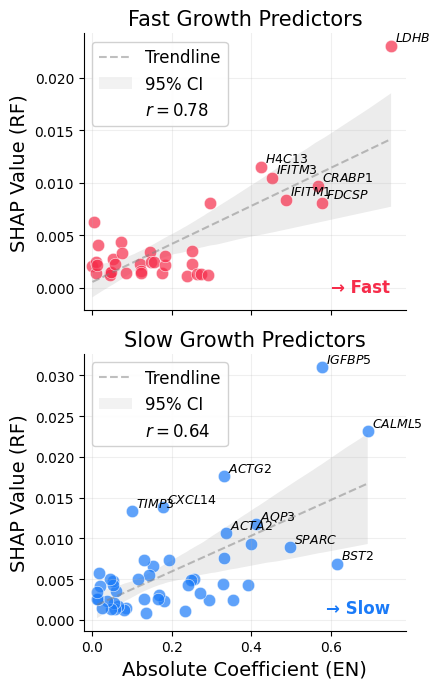

In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# 1. LOAD & PREP DATA
en_df = pd.read_csv("../results/1_doublingRate/EN_Full_Coefficients_for_GSEA.csv")
shap_df = pd.read_csv("../results/1_doublingRate/SHAP_Global_Gene_Importance.csv")

merged = pd.merge(en_df, shap_df, on="Gene")
merged['Abs_Coefficient'] = merged['Coefficient'].abs()

# Split into two groups
slow_genes = merged[merged['Coefficient'] > 0].copy()
fast_genes = merged[merged['Coefficient'] < 0].copy()

# 2. SET UP PLOT
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4.5, 7), sharex=True)

def plot_consensus(df, ax, title, color, label_text):
    # Calculate group-specific correlation
    r_val = df['Abs_Coefficient'].corr(df['Mean_Abs_SHAP'])
    
    # Regression line
    sns.regplot(data=df, x='Abs_Coefficient', y='Mean_Abs_SHAP', ax=ax,
                scatter=False, line_kws={'color':'gray', 'lw':1.5, 'linestyle':'--', 'alpha':0.5})
    
    # Scatter dots
    ax.scatter(df['Abs_Coefficient'], df['Mean_Abs_SHAP'], 
               c=color, s=80, alpha=0.7, edgecolors='white', linewidth=0.5)
    
    # Annotations (Threshold: SHAP > 0.01 or Abs_Coef > 0.4)
    top = df[(df['Mean_Abs_SHAP'] > 0.01) | (df['Abs_Coefficient'] > 0.4)]
    for i, row in top.iterrows():
        ax.text(row['Abs_Coefficient'] + 0.01, row['Mean_Abs_SHAP'] + 0.0005, 
                f"$\mathit{{{row['Gene']}}}$", fontsize=9, fontweight='bold')

    # Formatting
    ax.set_title(f"{title}", fontsize=15)
    ax.set_xlabel("Absolute Coefficient (EN)", fontsize=14)
    ax.grid(alpha=0.2)
    
    # Add group label indicator
    ax.text(0.95, 0.05, label_text, transform=ax.transAxes, 
            fontsize=12, fontweight='bold', color=color, ha='right', va='bottom')
    
    # Create legend elements
    legend_elements = [
        Line2D([0], [0], color='gray', lw=1.5, linestyle='--', alpha=0.5, label='Trendline'),
        Patch(facecolor='gray', alpha=0.1, label='95% CI'),
        Line2D([0], [0], linestyle='None', label=f'$r = {r_val:.2f}$'),
    ]

    #ax.legend(handles=legend_elements, loc='upper left', fontsize=12, frameon=False)
    # Add legend with a styled frame
    leg = ax.legend(handles=legend_elements, 
                    loc='upper left', 
                    fontsize=12, 
                    frameon=True,         # This enables the box
                    fancybox=True,        # Gives rounded corners (looks better)
                    edgecolor='#CCCCCC',  # Thin, light-gray border color
                    facecolor='white',    # Ensures the background is opaque white
                    framealpha=0.9)       # Slight transparency (optional, 0.9 is almost opaque)
    
    # Optional: If you want to force the legend to sit in front of grid lines
    #leg.set_zorder(10)

# 4. DRAW RIGHT PLOT (FAST)
plot_consensus(fast_genes, ax1, "Fast Growth Predictors", "#f62c4a", "→ Fast")
ax1.set_ylabel("SHAP Value (RF)", fontsize=14)
ax1.set_xlabel("") # Shared y-axis

# 3. DRAW LEFT PLOT (SLOW)
plot_consensus(slow_genes, ax2, "Slow Growth Predictors", "#1b7bf8", "→ Slow")
ax2.set_ylabel("SHAP Value (RF)", fontsize=14)



# 5. GLOBAL CLEANUP
sns.despine() # This removes the top and right spines by default
#plt.suptitle("Model Consensus", fontsize=20, y=0.96)
plt.xlim(left=-0.02)
plt.tight_layout()
plt.savefig("../results/1_doublingRate/Figure2_Consensus_Split.png", dpi=300, bbox_inches='tight')
plt.show()

<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
/var/folders/cz/vb9sgz_s0050f8rq5mdgr_hc0000gn/T/ipykernel_14788/3058276403.py:49: SyntaxWarning: invalid escape sequence '\m'
  axes[i].set_title(f"$\mathit{{{gene}}}$", fontsize=18, pad=20)
/var/folders/cz/vb9sgz_s0050f8rq5mdgr_hc0000gn/T/ipykernel_14788/3058276403.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["logDT"] = np.log1p(df["global_doubling_time"].astype(float))
/var/folders/cz/vb9sgz_s0050f8rq5mdgr_hc0000gn/T/ipykernel_14788/3058276403.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.con

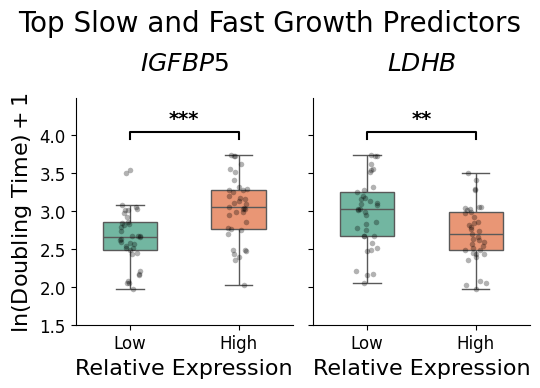

In [198]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# 1. LOAD DATA
# Ensure path is correct for your local environment
df = pd.read_csv("../data/procdata/1_doublingRate/rna_HVG2000_doubling_time_merged.csv", index_col=0)
df["logDT"] = np.log1p(df["global_doubling_time"].astype(float))

top_genes = ["IGFBP5", "LDHB"]
my_palette = ["#66c2a5", "#fc8d62"] # Clean Grey/Blue palette

# 2. CREATE THE FIGURE
fig, axes = plt.subplots(1, 2, figsize=(5.5, 4), sharey=True)

for i, gene in enumerate(top_genes):
    # Split into High/Low groups based on Median
    median_val = df[gene].median()
    df[f'{gene}_group'] = np.where(df[gene] > median_val, 'High', 'Low')
    
    # Calculate Significance (Mann-Whitney U is safer for biological noise)
    group_low = df[df[f'{gene}_group'] == 'Low']['logDT']
    group_high = df[df[f'{gene}_group'] == 'High']['logDT']
    u_stat, p_val = stats.mannwhitneyu(group_low, group_high)

    # 1. Determine the Asterisks
    if p_val < 0.001:
        sig_text = "***"
    elif p_val < 0.01:
        sig_text = "**"
    elif p_val < 0.05:
        sig_text = "*"
    else:
        sig_text = "ns"

    # 2. Add the Bracket and Text
    y_max = df['logDT'].max()
    y_bracket = y_max + 0.2  # Adjust this based on your data scale
    h = 0.1 # Height of the bracket "ticks"
    axes[i].set_ylim(1.5, y_max * 1.2)

    # Draw the line: [x1, x1, x2, x2], [y1, y2, y2, y1]
    axes[i].plot([0, 0, 1, 1], [y_bracket, y_bracket+h, y_bracket+h, y_bracket], lw=1.5, color='black')
    axes[i].text(0.5, y_bracket + h + 0.05, sig_text, ha='center', va='bottom', fontsize=14, fontweight='bold')

    # 3. Clean Title
    axes[i].set_title(f"$\mathit{{{gene}}}$", fontsize=18, pad=20)

    # Plot Boxplot
    sns.boxplot(data=df, x=f'{gene}_group', y='logDT', order=['Low', 'High'],
                ax=axes[i], palette=my_palette, width=0.5, fliersize=0)
    
    # Add Individual Points (Stripplot) for transparency
    sns.stripplot(data=df, x=f'{gene}_group', y='logDT', order=['Low', 'High'],
                  ax=axes[i], color='black', alpha=0.3, size=4, jitter=True)

    # Styling and Stats
    #axes[i].set_title(f"{gene}\n(p = {p_val:.5f})", fontsize=16)
    axes[i].set_xlabel(f"Relative Expression", fontsize=16)
    
    if i == 0:
        axes[i].set_ylabel(r"$\ln(\mathrm{Doubling\ Time}) + 1$", fontsize=16)
    else:
        axes[i].set_ylabel("")

    # Visual Clean-up
    sns.despine(ax=axes[i])
    axes[i].tick_params(labelsize=12)

plt.suptitle("Top Slow and Fast Growth Predictors", fontsize=20, y=0.96)
plt.tight_layout()
plt.savefig("../results/1_doublingRate/Top_2_Genes_Binary_Comparison.png", dpi=300, bbox_inches='tight')
plt.show()

Rank file saved. Total genes: 2000


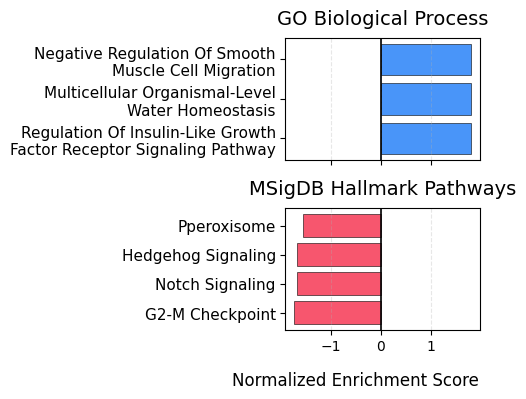

In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gseapy as gp
import textwrap

# 1. LOAD & PREPARE DATA
df_en = pd.read_csv("../results/1_doublingRate/EN_Full_Coefficients_for_GSEA.csv")
df_all = pd.read_csv("../data/procdata/1_doublingRate/rna_HVG2000_doubling_time_merged.csv", index_col=0)
all_hvg_genes = df_all.drop(columns=["global_doubling_time"]).columns.tolist()

# 2. VECTORIZED MERGING (Much faster than a loop)
# Create a base dataframe of all 2000 genes
rnk_final = pd.DataFrame({'Gene': all_hvg_genes})

# Map coefficients from your EN results (genes not in df_en will be NaN, then 0)
coef_map = dict(zip(df_en['Gene'], df_en['Coefficient']))
rnk_final['Score'] = rnk_final['Gene'].map(coef_map).fillna(0)

# 3. APPLY JITTER (Vectorized)
# Using a seed for reproducibility so your paper results don't change daily
np.random.seed(42)
rnk_final['Score'] = rnk_final['Score'] + np.random.normal(0, 1e-10, size=len(rnk_final))

# Sort descending: Slow drivers (positive) at top, Fast (negative) at bottom
rnk_final = rnk_final.sort_values(by='Score', ascending=False)

# Save for your records
rnk_final.to_csv("../results/1_doublingRate/EN_Ranking_for_GSEA.rnk", index=False, header=False, sep='\t')
print(f"Rank file saved. Total genes: {len(rnk_final)}")

# 4. RUN ENRICHMENT
libraries = {
    'GO_BP': 'GO_Biological_Process_2023',
    'Hallmark': 'MSigDB_Hallmark_2020'
}

# Increased min_size to 5 for better statistical robustness with 2000 genes
enr_go = gp.prerank(rnk=rnk_final, gene_sets=libraries['GO_BP'], 
                    permutation_num=1000, seed=42, min_size=3)

enr_hal = gp.prerank(rnk=rnk_final, gene_sets=libraries['Hallmark'], 
                     permutation_num=1000, seed=42, min_size=3)

# 5. PREPARE PLOT DATA (Logic remains same, but cleaner)
def prepare_plot_data(res, is_go=True):
    res_df = res.res2d

    if is_go:
        sig_df = res_df[res_df['FDR q-val'] < 0.25].copy()
    else:
    # Use 0.5 as a limit but prioritize the top NES values
        sig_df = res_df[res_df['FDR q-val'] < 0.5].copy()
    
    if sig_df.empty: return None

    # sort by NES
    top_pos = sig_df[sig_df['NES'] > 0].sort_values("NES", ascending=False)
    top_neg = sig_df[sig_df['NES'] < 0].sort_values("NES", ascending=True)
    plot_df = pd.concat([top_pos, top_neg]).sort_values("NES")

    if is_go:
        plot_df['Term'] = [
            "\n".join(textwrap.wrap(t.split(' (GO:')[0], width=35)) 
            for t in plot_df['Term']
        ]
    else:
        plot_df['Term'] = [
            "\n".join(textwrap.wrap(t.replace('HALLMARK_', '').replace('_', ' '), width=25))
            for t in plot_df['Term']
        ]
    return plot_df

df_go = prepare_plot_data(enr_go, is_go=True)
df_hal = prepare_plot_data(enr_hal, is_go=False)

# 4. CREATE VERTICALLY ALIGNED FIGURE
# Adjusted height_ratios based on which results are available
fig, axes = plt.subplots(2, 1, figsize=(5, 4.2), sharex=True, 
                         gridspec_kw={'height_ratios': [1, 1]})

color_slow = '#1b7bf8' # Your Blue (Slow)
color_fast = '#f62c4a' # Your Red (Fast)

# SUBPLOT A: GO_BP (Top)
if df_go is not None:
    colors_go = [color_slow if x > 0 else color_fast for x in df_go['NES']]
    axes[0].barh(df_go['Term'], df_go['NES'], color=colors_go, alpha=0.8, edgecolor='black', linewidth=0.5)
    axes[0].axvline(0, color='black', lw=1.2)
    axes[0].set_title('GO Biological Process', fontsize=14, loc='center', pad=10)
    axes[0].grid(axis='x', linestyle='--', alpha=0.3)
    #axes[0].text(0.02, 0.05, 'FDR < 0.25', transform=axes[0].transAxes, 
    #             fontsize=10.5, fontweight='bold', color='black', alpha=0.7)
    axes[0].tick_params(axis='y', labelsize=11)

# SUBPLOT B: Hallmark (Bottom)
if df_hal is not None:
    colors_hal = [color_slow if x > 0 else color_fast for x in df_hal['NES']]
    axes[1].barh(df_hal['Term'], df_hal['NES'], color=colors_hal, alpha=0.8, edgecolor='black', linewidth=0.5)
    axes[1].axvline(0, color='black', lw=1.2)
    axes[1].set_title('MSigDB Hallmark Pathways', fontsize=14, loc='center', pad=10)
    axes[1].grid(axis='x', linestyle='--', alpha=0.3)
    #axes[1].text(0.5, 0.05, 'FDR < 0.50', transform=axes[1].transAxes, 
    #             fontsize=10.5, fontweight='bold', color='black', alpha=0.7)
    axes[1].tick_params(axis='y', labelsize=11)

# Labels and Layout
fig.supxlabel('Normalized Enrichment Score', fontsize=12, y=0.03, x=0.72)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("../results/1_doublingRate/Figure3_GSEA_Enrichment.png", dpi=300, bbox_inches='tight')
plt.show()


<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
/var/folders/cz/vb9sgz_s0050f8rq5mdgr_hc0000gn/T/ipykernel_14788/1312518121.py:42: SyntaxWarning: invalid escape sequence '\m'
  f"$\mathit{{{row['Gene']}}}$",
/var/folders/cz/vb9sgz_s0050f8rq5mdgr_hc0000gn/T/ipykernel_14788/1312518121.py:50: SyntaxWarning: invalid escape sequence '\m'
  f"$\mathit{{{row['Gene']}}}$ (Non-linear)",


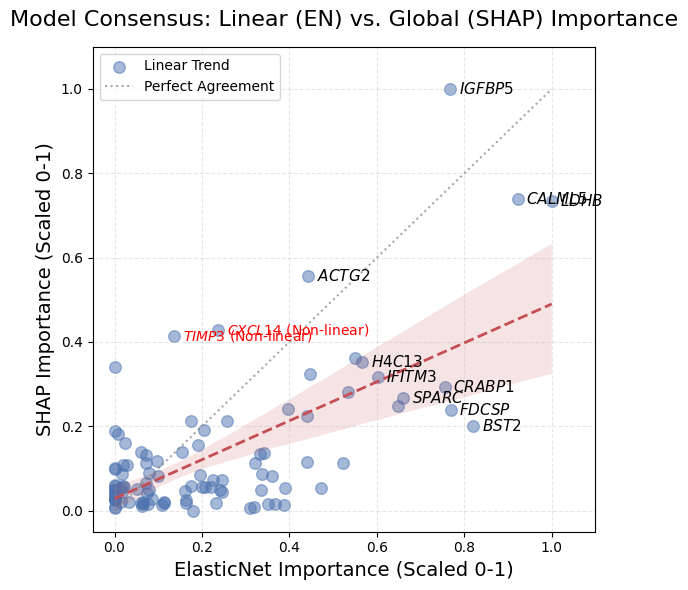

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD THE DATA
en_df = pd.read_csv("../results/1_doublingRate/EN_Full_Coefficients_for_GSEA.csv")
shap_df = pd.read_csv("../results/1_doublingRate/SHAP_Global_Gene_Importance.csv")

# 2. MERGE AND CALCULATE ABSOLUTE IMPACT
merged = pd.merge(en_df, shap_df, on="Gene")
merged['Abs_Coef'] = merged['Coefficient'].abs()

# 3. APPLY MIN-MAX SCALING (0 to 1)
# Scale ElasticNet Absolute Coefficients
c_min, c_max = merged['Abs_Coef'].min(), merged['Abs_Coef'].max()
merged['EN_Score'] = (merged['Abs_Coef'] - c_min) / (c_max - c_min)

# Scale SHAP Global Importance
s_min, s_max = merged['Mean_Abs_SHAP'].min(), merged['Mean_Abs_SHAP'].max()
merged['SHAP_Score'] = (merged['Mean_Abs_SHAP'] - s_min) / (s_max - s_min)

# 4. PLOTTING
plt.figure(figsize=(6, 6))

# Main Scatter Plot with Regression Line
sns.regplot(data=merged, x='EN_Score', y='SHAP_Score', 
            scatter_kws={'alpha':0.5, 's':70, 'color':'#4c72b0'}, 
            line_kws={'color':'#c44e52', 'lw':2, 'linestyle':'--'},
            label='Linear Trend')

# Add the 1:1 "Perfect Agreement" Line
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle=':', alpha=0.7, label='Perfect Agreement')

# --- 5. ANNOTATE TOP CONSENSUS GENES ---
# We define consensus as the average of the two scores
merged['Consensus_Score'] = (merged['EN_Score'] + merged['SHAP_Score']) / 2
top_10 = merged.sort_values('Consensus_Score', ascending=False).head(10)

for i, row in top_10.iterrows():
    plt.text(row['EN_Score'] + 0.02, row['SHAP_Score'], 
             f"$\mathit{{{row['Gene']}}}$", 
             fontsize=11, fontweight='bold', va='center')

# --- 6. IDENTIFY & ANNOTATE DISAGREEMENTS (Outliers) ---
# High SHAP but low EN (Non-linear effects)
outliers = merged[(merged['SHAP_Score'] > 0.4) & (merged['EN_Score'] < 0.3)]
for i, row in outliers.iterrows():
    plt.text(row['EN_Score'] + 0.02, row['SHAP_Score'], 
             f"$\mathit{{{row['Gene']}}}$ (Non-linear)", 
             fontsize=10, color='red', va='center')

# AESTHETICS
plt.title("Model Consensus: Linear (EN) vs. Global (SHAP) Importance", fontsize=16, pad=15)
plt.xlabel("ElasticNet Importance (Scaled 0-1)", fontsize=14)
plt.ylabel("SHAP Importance (Scaled 0-1)", fontsize=14)
plt.xlim(-0.05, 1.1)
plt.ylim(-0.05, 1.1)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig("../results/1_doublingRate/Figure2f_Model_Consensus_Scatter.png", dpi=300)
plt.show()

# 7. SAVE FINAL SCORES FOR KEGG/GO
merged.to_csv("../results/1_doublingRate/Final_Gene_Robustness_Scores.csv", index=False)

### Define fast vs slow models (highest 1/3 vs lowes 1/3)

In [14]:
# Calculate tertile thresholds
low_threshold = df["global_doubling_time"].quantile(1/3)
high_threshold = df["global_doubling_time"].quantile(2/3)

# Filter for only "Fast" (bottom 1/3) and "Slow" (top 1/3)
df_filtered = df[(df["global_doubling_time"] <= low_threshold) | 
                 (df["global_doubling_time"] >= high_threshold)].copy()

# Create binary target: 0 for Fast, 1 for Slow
df_filtered['target'] = (df_filtered["global_doubling_time"] >= high_threshold).astype(int)

X = df_filtered.drop(columns=["global_doubling_time", "target"])
y = df_filtered['target']

print(f"Original samples: {len(df)}")
print(f"Samples after removing middle tertile: {len(df_filtered)}")

Original samples: 75
Samples after removing middle tertile: 50


### ElasticNet

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Simplified Pipeline
# Since features are already selected, we just scale and classify
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='elasticnet', 
        solver='saga',      
        l1_ratio=0.5,       # 0.5 is a balance; 1.0 would be pure Lasso
        max_iter=10000, 
        random_state=42
    ))
])

# Execution
loo = LeaveOneOut()
cv_results = cross_val_score(pipe, X, y, cv=loo, scoring='accuracy', n_jobs=-1)

print(f"Number of samples in 1/3 extremes: {len(y)}")
print(f"Elastic Net LOOCV Mean Accuracy: {cv_results.mean():.4f}")
print(f"Elastic Net LOOCV Accuracy std: {cv_results.std():.4f}")

Number of samples in 1/3 extremes: 50
Elastic Net LOOCV Mean Accuracy: 0.7200
Elastic Net LOOCV Accuracy std: 0.4490


In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
import numpy as np

# 1. Define the Pipeline (Same as your successful Elastic Net)
pipe_en = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='elasticnet', 
        solver='saga',      
        l1_ratio=0.5,       
        max_iter=10000, 
        random_state=42
    ))
])

# 2. Configure the Repeated Stratified 5-Fold
# 5 folds = 10 samples per test set
# 20 repeats = 100 total models trained
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=42)

# 3. Execution
cv_results = cross_val_score(pipe_en, X, y, cv=rskf, scoring='accuracy', n_jobs=-1)

# 4. Results Summary
print(f"Mean Accuracy: {cv_results.mean():.4f}")
print(f"Standard Deviation: {cv_results.std():.4f}")
print(f"95% Confidence Interval: [{cv_results.mean() - 1.96*cv_results.std():.4f}, {cv_results.mean() + 1.96*cv_results.std():.4f}]")



Mean Accuracy: 0.6360
Standard Deviation: 0.1261
95% Confidence Interval: [0.3888, 0.8832]


### Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Standard RF Pipeline
pipe_rf = Pipeline([
    ('scaler', StandardScaler()), # Not strictly necessary for RF, but keeps things consistent
    ('clf', RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1))
])

rf_results = cross_val_score(pipe_rf, X, y, cv=loo, scoring='accuracy')
print(f"Standard RF LOOCV Accuracy: {rf_results.mean():.4f}")
print(f"Standard RF LOOCV Accuracy std: {rf_results.std():.4f}")

Standard RF LOOCV Accuracy: 0.6400
Standard RF LOOCV Accuracy std: 0.4800


### Lassoed RF

In [22]:
from sklearn.feature_selection import SelectFromModel

# Lassoed RF Pipeline
pipe_lasso_rf = Pipeline([
    ('scaler', StandardScaler()),
    # Stage 1: Lasso selects the features
    ('selector', SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', random_state=42))),
    # Stage 2: Random Forest trains on the selected subset
    ('clf', RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1))
])

lasso_rf_results = cross_val_score(pipe_lasso_rf, X, y, cv=loo, scoring='accuracy')
print(f"Lassoed RF LOOCV Accuracy: {lasso_rf_results.mean():.4f}")
print(f"Lassoed RF LOOCV Accuracy std: {lasso_rf_results.std():.4f}")

Lassoed RF LOOCV Accuracy: 0.6800
Lassoed RF LOOCV Accuracy std: 0.4665


In [16]:
pipe.fit(X, y)
# Get the coefficients
coefs = pipe.named_steps['clf'].coef_[0]
gene_importance = pd.Series(coefs, index=X.columns).sort_values(ascending=False)

print("Top genes associated with SLOW growth:")
print(gene_importance.head(10))
print("\nTop genes associated with FAST growth:")
print(gene_importance.tail(10))

Top genes associated with SLOW growth:
CALML5        0.292963
NTN4          0.262756
NRP1          0.238721
ADGRG2        0.228179
ZNF503        0.224444
AC068631.3    0.222288
TNS4          0.212450
GPR87         0.203632
KIF26B        0.188799
IGFBP7        0.181383
dtype: float64

Top genes associated with FAST growth:
STOX2    -0.133561
MCOLN2   -0.138085
CDCA7    -0.151675
ALDOC    -0.155028
TFAP2B   -0.167080
DUSP5    -0.198332
PPM1K    -0.213598
HERC5    -0.213950
LDHB     -0.216202
GALM     -0.257828
dtype: float64


In [17]:
non_zero = (gene_importance != 0).sum()
print(f"Genes used by the model: {non_zero} out of 2000")

Genes used by the model: 115 out of 2000


In [11]:
# 1. Selector using continuous values for higher statistical power
class ContinuousCorrelationSelector(BaseEstimator, TransformerMixin):
    def __init__(self, n_top=200):
        self.n_top = n_top
        self.selected_features_ = None

    def fit(self, X, y):
        # Use fillna(0) to handle features with zero variance in a fold
        correlations = X.corrwith(y).abs().fillna(0).sort_values(ascending=False)
        self.selected_features_ = correlations.head(self.n_top).index
        return self

    def transform(self, X):
        return X[self.selected_features_]

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Pipeline: Scaling is CRITICAL for Elastic Net 
# (otherwise features with larger scales dominate the penalty)
pipe_en = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', ContinuousCorrelationSelector(n_top=2000)), # Optional: reuse your selector
    ('clf', LogisticRegression(
        penalty='elasticnet', 
        solver='saga',      # 'saga' is required for elasticnet penalty
        l1_ratio=0.5,       # Balance between L1 and L2
        max_iter=10000, 
        random_state=42
    ))
])

# 2. Leave-One-Out Strategy
loo = LeaveOneOut()

# 3. Execution
# Note: roc_auc with LOOCV can be tricky because each fold only has 1 sample.
# Using 'accuracy' or calculating manual probabilities is standard here.
cv_results = cross_val_score(pipe_en, X, y, cv=loo, scoring='accuracy', n_jobs=-1)

print(f"LOOCV Mean Accuracy: {cv_results.mean():.4f}")

ValueError: 
All the 50 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/guanqiaofeng/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/guanqiaofeng/miniconda3/lib/python3.13/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/guanqiaofeng/miniconda3/lib/python3.13/site-packages/sklearn/pipeline.py", line 613, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
  File "/Users/guanqiaofeng/miniconda3/lib/python3.13/site-packages/sklearn/pipeline.p

In [8]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

# 1. Selector using continuous values for higher statistical power
class ContinuousCorrelationSelector(BaseEstimator, TransformerMixin):
    def __init__(self, n_top=200):
        self.n_top = n_top
        self.selected_features_ = None

    def fit(self, X, y):
        # Use fillna(0) to handle features with zero variance in a fold
        correlations = X.corrwith(y).abs().fillna(0).sort_values(ascending=False)
        self.selected_features_ = correlations.head(self.n_top).index
        return self

    def transform(self, X):
        return X[self.selected_features_]

class CategoricalRF(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=500, random_state=42):
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.model = RandomForestClassifier(n_estimators=self.n_estimators, random_state=self.random_state)
        
    def fit(self, X, y):
        self.threshold_ = np.median(y)
        y_cat = (y > self.threshold_).astype(int)
        
        # Check if we actually have two classes to train on
        unique_y = np.unique(y_cat)
        if len(unique_y) < 2:
            raise ValueError("Fold contains only one class. Increase data or check stratification.")
            
        self.classes_ = unique_y
        self.model.fit(X, y_cat)
        return self

    def predict(self, X):
        return self.model.predict(X)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

# --- DATA PREP ---
y_continuous = df["global_doubling_time"]
# Create this ONLY for the CV splitting logic
y_stratify = (y_continuous > y_continuous.median()).astype(int) 

X_var_filtered = select_variant_features(df.drop(columns=["global_doubling_time"]), n_top=15000)

# --- PIPELINE ---
pipe = Pipeline([
    ('selector', ContinuousCorrelationSelector(n_top=200)), # Select top 100 features based on continuous correlation
    ('clf', CategoricalRF(n_estimators=500, random_state=42))
])

# --- EXECUTION ---
# Stratify by the categorical version, but pass the continuous version to the pipe
rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=42)

cv_results = cross_validate(
    pipe, 
    X_var_filtered, 
    y_continuous, 
    cv=rkf.split(X_var_filtered, y_stratify), # Use split() to force stratification
    scoring='roc_auc', 
    return_estimator=True, 
    n_jobs=-1
)

print(cv_results['test_score'])
#print(f"Mean AUC: {cv_results['test_score'].mean():.3f} +/- {cv_results['test_score'].std():.3f}")

Selected top 15000 most variant features.
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan]


In [7]:
print(np.isinf(df["global_doubling_time"]).sum())

0


In [47]:
print(df.isnull().sum().sum())

0


### Select feature based on doubling time correlation

In [33]:
def important_features(train, target_series, thres):
    # Calculate correlations for all genes at once (much faster)
    correlations = train.corrwith(target_series)
    
    # Convert to DataFrame for easy filtering/plotting later
    corr_df = correlations.to_frame(name='Correlation')

    # Count thresholds
    num_pos = (corr_df['Correlation'] > thres).sum()
    num_neg = (corr_df['Correlation'] < -thres).sum()

    print(f'Selected threshold: {thres}')
    print(f'Num features with positive correlation > threshold: {num_pos}')
    print(f'Num features with |negative correlation| > threshold: {num_neg}')
    print(f'Total features: {len(train.columns)}')
    print(f'Total selected: {num_pos + num_neg}')

    # Identify features that pass threshold
    keep = corr_df[corr_df['Correlation'].abs() > thres].index
    
    return train[keep]

y = df["global_doubling_time"]
X = df.drop(columns=["global_doubling_time"])
X_selected = important_features(X, y, thres=0.2)


Selected threshold: 0.2
Num features with positive correlation > threshold: 1648
Num features with |negative correlation| > threshold: 335
Total features: 14999
Total selected: 1983


In [ ]:
# read in the doubling time data
# Save your local variables to CSV
X_train = pd.read_csv("data/procdata/1_doublingRate/X_train_processed.csv", index_col=0)
X_test = pd.read_csv("data/procdata/1_doublingRate/X_test_processed.csv", index_col=0)
y_train = pd.read_csv("data/procdata/1_doublingRate/y_train.csv", index_col=0)
y_test = pd.read_csv("data/procdata/1_doublingRate/y_test.csv", index_col=0)

# Create binary labels: 1 for Slow (High DT), 0 for Fast (Low DT)
threshold = y_train.median()
y_train_cat = (y_train > threshold).astype(int)
y_test_cat = (y_test > threshold).astype(int)

### ElasticNet

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# 'l1_ratio' balances Lasso (1.0) and Ridge (0.0). 0.5 is a clean middle ground.
en_clf = LogisticRegression(penalty='elasticnet', 
                            solver='saga', 
                            l1_ratio=0.5, 
                            C=1.0, 
                            max_iter=10000, 
                            random_state=42)

en_clf.fit(X_train, y_train_cat.values.ravel())

# Get probabilities for the AUC calculation
en_probs = en_clf.predict_proba(X_test)[:, 1]
en_auc = roc_auc_score(y_test_cat, en_probs)

print(f"Categorical ElasticNet AUC: {en_auc:.3f}")

Categorical ElasticNet AUC: 0.841


### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score

clf = RandomForestClassifier(n_estimators=500, random_state=42)
clf.fit(X_train, y_train_cat.values.ravel())

probs = clf.predict_proba(X_test)[:, 1]
print(f"Test AUC-ROC: {roc_auc_score(y_test_cat, probs):.3f}")

Test AUC-ROC: 0.818


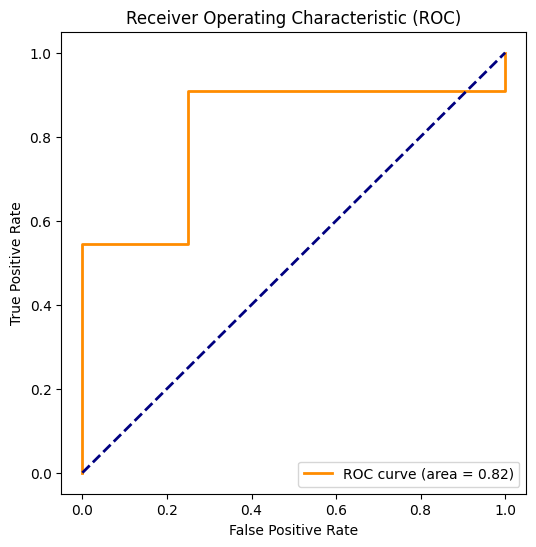

In [6]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test_cat, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

### Lassoed RF

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Step 1: Feature Selection using Lasso (Logistic Regression with L1)
# Use a small C (e.g., 0.1) to be aggressive with feature selection
lasso_selector = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
lasso_selector.fit(X_train, y_train_cat.values.ravel())

# Identify genes with non-zero coefficients
lasso_genes = X_train.columns[lasso_selector.coef_[0] != 0]
print(f"Lasso selected {len(lasso_genes)} essential genes for classification.")

# Step 2: Train Random Forest on ONLY those genes
lrf_clf = RandomForestClassifier(n_estimators=500, random_state=42)
lrf_clf.fit(X_train[lasso_genes], y_train_cat.values.ravel())

# Step 3: Evaluate
lrf_probs = lrf_clf.predict_proba(X_test[lasso_genes])[:, 1]
lrf_auc = roc_auc_score(y_test_cat, lrf_probs)

print(f"Lassoed RF (Categorical) AUC: {lrf_auc:.3f}")

Lasso selected 10 essential genes for classification.
Lassoed RF (Categorical) AUC: 0.909


In [13]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin

# 1. Define a Custom Selector to find those "10 essential genes" inside the CV
class LassoSelector(BaseEstimator, TransformerMixin):
    def __init__(self, C=1):
        self.C = C
        self.model = LogisticRegression(penalty='l1', solver='liblinear', C=self.C, random_state=42)
    def fit(self, X, y):
        self.model.fit(X, y)
        self.selected_features_ = X.columns[self.model.coef_[0] != 0]
        return self
    def transform(self, X):
        return X[self.selected_features_]

# 2. Build the Pipeline
# This treats the Lasso + RF as a single "model"
pipeline = Pipeline([
    ('selector', LassoSelector(C=1)),
    ('classifier', RandomForestClassifier(n_estimators=500, random_state=42))
])

# 3. Setup Repeated 5-Fold CV (Repeated 20 times)
rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=42)

# 4. Run it
cv_results = cross_val_score(pipeline, X_train, y_train_cat.values.ravel(), 
                             cv=rkf, scoring='roc_auc', n_jobs=-1)

print(f"Mean AUC: {cv_results.mean():.3f} +/- {cv_results.std():.3f}")

Mean AUC: 0.763 +/- 0.145


In [6]:
import matplotlib.pyplot as plt

models = ['ElasticNet', 'Random Forest', 'Lassoed RF']
preds = [en_pred, rf_pred, lrf_pred]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, ax in enumerate(axes):
    ax.scatter(y_test, preds[i], alpha=0.6, color='steelblue')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_title(f"{models[i]}\nPearson r: {stats.pearsonr(y_test.values.ravel(), preds[i])[0]:.3f}")
    ax.set_xlabel("Actual Doubling Time")
    if i == 0: ax.set_ylabel("Predicted Doubling Time")

plt.tight_layout()
plt.show()

NameError: name 'lrf_pred' is not defined

### Set target and features

In [26]:
y = df["global_doubling_time"]
X = df.drop(columns=["global_doubling_time"])

In [27]:
def important_features(train, target_series, thres):
    # Calculate correlations for all genes at once (much faster)
    correlations = train.corrwith(target_series)
    
    # Convert to DataFrame for easy filtering/plotting later
    corr_df = correlations.to_frame(name='Correlation')

    # Count thresholds
    num_pos = (corr_df['Correlation'] > thres).sum()
    num_neg = (corr_df['Correlation'] < -thres).sum()

    print(f'Selected threshold: {thres}')
    print(f'Num features with positive correlation > threshold: {num_pos}')
    print(f'Num features with |negative correlation| > threshold: {num_neg}')
    print(f'Total features: {len(train.columns)}')
    print(f'Total selected: {num_pos + num_neg}')

    # Identify features that pass threshold
    keep = corr_df[corr_df['Correlation'].abs() > thres].index
    
    return train[keep]

In [32]:
from sklearn.model_selection import train_test_split

# 1. Split into Training and Testing sets (e.g., 80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

# 2. Run your function ONLY on the training data
# Let's use a threshold of 0.3 as a starting point
X_train_selected = important_features(X_train, y_train, thres=0.2)

# 3. Filter the test set to include only those same genes
# This ensures both matrices have the same columns for the model
selected_genes = X_train_selected.columns
X_test_selected = X_test[selected_genes]

Selected threshold: 0.2
Num features with positive correlation > threshold: 2517
Num features with |negative correlation| > threshold: 577
Total features: 19692
Total selected: 3094


In [30]:
# Check the new top protein-coding genes
print(X_train_selected.corrwith(y_train).abs().sort_values(ascending=False).head(10))

ADAMTS17    0.524467
GPX5        0.514205
LVRN        0.499639
LMOD1       0.499043
ANGPT2      0.490222
WTIP        0.490063
TNS4        0.488791
CYP7A1      0.485198
MFAP4       0.481482
CDH13       0.481314
dtype: float64


In [33]:
def corr_features_fast(X_subset, thres):
    # 1. Compute correlation matrix
    corr_matrix = X_subset.corr().abs()

    # 2. Select upper triangle of correlation matrix
    # (This avoids comparing a gene to itself or comparing A-B and B-A)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # 3. Find features with correlation greater than threshold
    to_drop = [column for column in upper.columns if any(upper[column] > thres)]

    print(f'Original number of features: {X_subset.shape[1]}')
    print(f'Num highly correlated features to drop: {len(to_drop)}')
    
    # 4. Drop features 
    X_filtered = X_subset.drop(columns=to_drop)
    print(f'Number of features remaining: {X_filtered.shape[1]}')

    return X_filtered

In [34]:
# 1. Run the redundancy filter on the Training Set ONLY
# We use a high threshold (e.g., 0.85) to remove near-duplicates
X_train_final = corr_features_fast(X_train_selected, thres=0.85)

# 2. Get the list of genes that survived the filter
final_genes = X_train_final.columns

# 3. Filter the Test Set to match the new Training Set
X_test_final = X_test_selected[final_genes]

print(f"Final feature count for modeling: {len(final_genes)}")

Original number of features: 3094
Num highly correlated features to drop: 382
Number of features remaining: 2712
Final feature count for modeling: 2712


### Scaling

In [35]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data ONLY, then transform both
X_train_final_scaled = scaler.fit_transform(X_train_final)
X_test_final_scaled = scaler.transform(X_test_final)

# (Optional) Convert back to DataFrame if you want to keep gene names
X_train_final_scaled = pd.DataFrame(X_train_final_scaled, 
                                    index=X_train_final.index, 
                                    columns=X_train_final.columns)
X_test_final_scaled = pd.DataFrame(X_test_final_scaled, 
                                   index=X_test_final.index, 
                                   columns=X_test_final.columns)

In [37]:
# Save your local variables to CSV
X_train_final_scaled.to_csv("data/procdata/1_doublingRate/X_train_processed.csv")
X_test_final_scaled.to_csv("data/procdata/1_doublingRate/X_test_processed.csv")
y_train.to_csv("data/procdata/1_doublingRate/y_train.csv")
y_test.to_csv("data/procdata/1_doublingRate/y_test.csv")